# Single Experiment: Model Training and Evaluation

This notebook runs a single controlled experiment for either a
Quantum or Classical model on the basket option dataset.

The goal is:

- Train one model configuration
- Evaluate train/test performance
- Visualize predictions
- Inspect model behavior

This notebook is intended for interactive experimentation and debugging.

In [1]:
import sys
import os
from pathlib import Path
project_root = Path.cwd().parents[0]  

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.run.params import DataParams, QuantumModelParams, TrainingParams, Params, ClassicModelParams
from src.run.RunParams import run_params
from src.run.Result import Result
from src.run.result_repository import load_all_results, results_to_df, latest_result
from src.visualize.metrics import get_metrics
from src.run.result_repository import reload_model
import numpy as np
import matplotlib.pyplot as plt


## 1. Experiment Configuration

We define:

- Data parameters (tickers, time range, number of samples)
- Model parameters (Quantum or Classical)
- Training parameters (learning rate and number of steps)

All settings are bundled in a `Params` object to ensure full reproducibility.

In [2]:
dataParams = DataParams(
    tickers = ["IBM", "NKE"],
    start_date="2000-01-01",
    end_date="2025-01-01",
    n_samples=25000,
    use_percentage=True,
    option_type = "worst",
    noiseScale=0.00,
    split_mode="random",
)

### Model Selection

You can switch between:

- Quantum model
- Classical Ferguson model
- Classical Culkin model

Only one configuration should be active at a time.

In [3]:

modelParams = QuantumModelParams(
    layers = 1,
    n_trainable_blocks=10,
    encoding_base=1                  # 1 for unary, 3 for ternery
)

# Uncomment für Classic
# modelParams =ClassicModelParams(
#     units=100,
#     dropout=0.0,
#     model_name="classic_ferguson"
#     # model_name="classic_culkin"
# )


trainingParams = TrainingParams(
    learning_rate=0.001,
    total_steps=5_000,
)

params = Params(
    seed=9598765,
    data=dataParams,
    model_params=modelParams,
    training_params=trainingParams,


)

## 2. Training

The pipeline automatically:

- Loads the dataset
- Builds a train/test split
- Instantiates the selected model
- Trains using the specified optimizer

After training, R² scores for train and test sets are printed.

In [4]:

result= run_params(params)
print(f"train r2: {result.metrics['train']['r2']}")
print(f"test r2: {result.metrics['test']['r2']}")

Data loaded from /Users/moritzmaier/Uni/Basket-Option-Pricing-with-Quantum-Circuits/data/processed/IBM_NKE_2000-01-01_2025-01-01_win21_mat63.pkl
Params: 180
train r2: 0.9637426733970642
test r2: 0.96355140209198


## 3. Saving the Result

The trained model is saved locally, including:

- Model parameters
- Metrics
- Learned weights
- Training history

This allows later reloading and comparison.

In [5]:
result.save("local")

Result saved to: /Users/moritzmaier/Uni/Basket-Option-Pricing-with-Quantum-Circuits/results/local/quantum/IBM-NKE/2000-01-01/2025-01-01/worst/seed9598765_20260306_154902


In [6]:
allresults = load_all_results("local")
df = results_to_df(allresults,True, True)

# Use the most recent run in the local results folder.
result: Result = latest_result(allresults)

## 4. Reloading and Re-evaluation

To verify reproducibility, the model is reloaded from disk.
Predictions are recomputed using the stored weights.


In [7]:
# Reload the model architecture and data split to reproduce predictions from saved weights.
model, x_train, x_test, y_train, y_test = reload_model(result)

# Ensure weights are plain numpy arrays (JSON/pickle loading can change types).
result.weights = [np.array(w) for w in result.weights]

# Fit the input/output scaler on the training data before generating predictions.
model.fit_scaler(x_train, y_train)
predictions_test=  model.get_predictions(weights=result.weights, x=x_test)
predictions_train = model.get_predictions(weights=result.weights, x=x_train)


option_type = result.params.data.option_type
noise_value = result.params.data.noiseScale
n_samples = result.params.data.n_samples
# 1D sicherstellen
y_train = np.ravel(y_train)
y_test = np.ravel(y_test)
predictions_train = np.ravel(predictions_train)
predictions_test = np.ravel(predictions_test)

Data loaded from /Users/moritzmaier/Uni/Basket-Option-Pricing-with-Quantum-Circuits/data/processed/IBM_NKE_2000-01-01_2025-01-01_win21_mat63.pkl


## 5. Prediction vs True Values

To compare predicted and true basket option prices
for both train and test sets.

A perfect model would lie on the diagonal.
Deviation from the diagonal indicates approximation error.

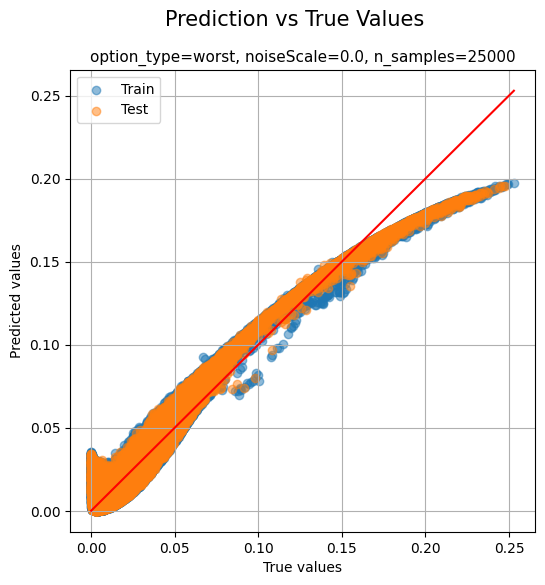

0.9637426733970642
0.96355140209198


In [8]:

fig, ax = plt.subplots(figsize=(6, 6))

# x-axis: true values, y-axis: predicted values

# Train
ax.scatter(
    y_train,
    predictions_train,
    alpha=0.5,
    label="Train",
)

# Test
ax.scatter(
    y_test,
    predictions_test,
    alpha=0.5,
    label="Test",
)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="-", color="red")

ax.set_xlabel("True values")
ax.set_ylabel("Predicted values")
ax.legend()
ax.grid(True)

# --- Titelstruktur wie bei deinen anderen Plots ---
fig.suptitle("Prediction vs True Values", fontsize=15)

ax.set_title(
    f"option_type={option_type}, noiseScale={noise_value}, n_samples={n_samples}",
    fontsize=11,
)

# plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

metrics = get_metrics(
    y_train=y_train, predictions_train=predictions_train,
    y_test=y_test, predictions_test=predictions_test
)
print(metrics["train"]["r2"])
print(metrics["test"]["r2"])

## 6. 3D Feature Visualization

Visualize the learned pricing surface
as a function of two selected input features.


In [9]:
from src.visualize.visualize import plot_3d
# Visualize predictions over two selected feature dimensions.
x1 = x_test[:, 0]
x2 = x_test[:, 1]

y_true = y_test
y_pred = predictions_test
plot_3d(x1,x2,y_true,y_pred)